# Amazon Sentiment Classification 
**Author:** Jeongwoo Kim  
**Date:** 2025-12-01

## Project Overview

Online reviews play a major role in shaping customer decisions, especially on large e-commerce platforms like Amazon. Understanding whether a review expresses a positive or negative opinion can help businesses improve products, respond to customer concerns, and better understand overall consumer sentiment.

In this project, I analyze a dataset of more than 568,000 Amazon product reviews to explore how customers communicate sentiment through written text. The dataset includes review scores, helpfulness ratings, summaries, and full review text, providing a rich source of information for examining patterns in customer feedback.

The goal of this project is to preprocess the text data, explore the structure of the dataset, and develop a classification approach that can determine whether a review is positive or negative based solely on its content. By identifying sentiment patterns at scale, companies can gain insights that support product improvement, marketing decisions, and overall customer experience.

## Dataset Overview

**Dataset**: `Reviews.csv`

**Source**: [Kaggle - Amazon Product Reviews](https://www.kaggle.com/datasets/arhamrumi/amazon-product-reviews) 

**Size**: 568,454 rows × 10 columns

**Target**: Sentiment label derived from the Score column (positive vs negative)

In [89]:
import pandas as pd
import numpy as np

df = pd.read_csv("Reviews.csv")

print("Shape:", df.shape)
print("\n Columns:", list(df.columns))

display(df.head())

print("\n Data types and missing values:")
display(df.isnull().sum().to_frame("Missing Values").join(df.dtypes.to_frame("Type")))

print("\n Summary statistics:")
display(df.describe().T)

df["Text_length"] = df["Text"].str.len()
print(df["Text_length"].describe())

Shape: (568454, 10)

 Columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...



 Data types and missing values:


,Missing Values,Type
Id,0,int64
ProductId,0,object
UserId,0,object
ProfileName,26,object
HelpfulnessNumerator,0,int64
HelpfulnessDenominator,0,int64
Score,0,int64
Time,0,int64
Summary,27,object
Text,0,object



 Summary statistics:


,count,mean,std,min,25%,50%,75%,max
Id,568454.0,2.842275e+05,1.640987e+05,1.0,1.421142e+05,2.842275e+05,4.263408e+05,5.684540e+05
HelpfulnessNumerator,568454.0,1.743817e+00,7.636513e+00,0.0,0.000000e+00,0.000000e+00,2.000000e+00,8.660000e+02
HelpfulnessDenominator,568454.0,2.228810e+00,8.289740e+00,0.0,0.000000e+00,1.000000e+00,2.000000e+00,9.230000e+02
Score,568454.0,4.183199e+00,1.310436e+00,1.0,4.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00
Time,568454.0,1.296257e+09,4.804331e+07,939340800.0,1.271290e+09,1.311120e+09,1.332720e+09,1.351210e+09


count    568454.000000
mean        436.222083
std         445.339741
min          12.000000
25%         179.000000
50%         302.000000
75%         527.000000
max       21409.000000
Name: Text_length, dtype: float64


## Features Engineering
In this step, I cleaned the dataset and transformed the text-based features to prepare them for modeling.

First, I removed columns that do not contribute to the sentiment prediction task, such as Id, UserId, ProductId, ProfileName, and the helpfulness-related fields. These variables serve primarily as identifiers or metadata and do not provide meaningful information about the review’s sentiment.

In [90]:
# Drop unnecessary columns

drop_cols = ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Time']

df = df.drop(columns=drop_cols)


The 27 rows with missing summaries account for only 0.005% of the entire dataset, so removing them does not meaningfully affect class distribution. Therefore, these rows were dropped to avoid introducing unnecessary noise into the model.

In [91]:
df = df[['Score', 'Summary', 'Text']]

before = df.shape[0]

df = df.dropna(subset=['Summary', 'Text', 'Score'])

after = df.shape[0]

print(f"Dropped rows: {before - after}")
print(f"Remaining rows: {after}")

Dropped rows: 27
Remaining rows: 568427


To prepare the target variable, I removed all reviews with a score of 3 because they represent neutral sentiment and can introduce noise into a binary classification task. After removing these ambiguous cases, I converted the scores into a sentiment label: scores of 4–5 were mapped to positive (1), and scores of 1–2 were mapped to negative (0).

In [92]:
df = df[df['Score'] != 3]

df['Sentiment'] = df['Score'].apply(lambda x: 1 if x > 3 else 0)

## Target EDA & Visualization

The target variable shows a highly imbalanced distribution, with approximately 84% positive reviews and 16% negative reviews.

However, because of this imbalance, accuracy alone is not a reliable evaluation metric. Therefore, precision, recall, and F1-score were used to thoroughly evaluate model performance.

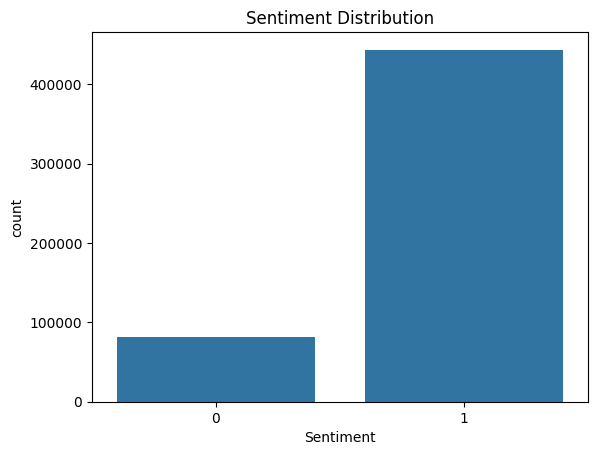

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df["Sentiment"])
plt.title("Sentiment Distribution")
plt.show()

In [94]:
df["Sentiment"].value_counts(normalize=True)

Sentiment
1    0.844021
0    0.155979
Name: proportion, dtype: float64

## Feature EDA & Visualization

Before moving on to modeling, I performed exploratory data analysis to check whether the Summary and Text fields actually provide useful information for sentiment prediction. Since both fields contain review content written by users, it was important to examine how much unique and meaningful information each one contributes, and whether using both would benefit the model.

In [95]:
summary_vocab = set(" ".join(df["Summary"].astype(str)).split())
text_vocab = set(" ".join(df["Text"].astype(str)).split())

print("Unique words in Summary:", len(summary_vocab))
print("Unique words in Text:", len(text_vocab))

Unique words in Summary: 98263
Unique words in Text: 553862


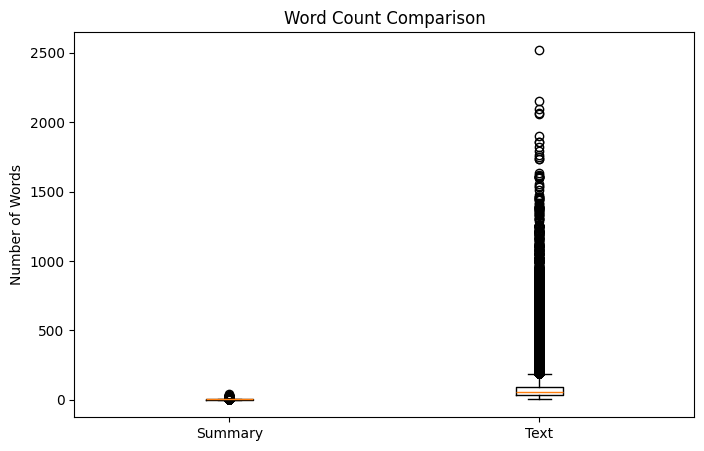

In [96]:
df["Summary_wordcount"] = df["Summary"].astype(str).apply(lambda x: len(x.split()))
df["Text_wordcount"] = df["Text"].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
plt.boxplot([df["Summary_wordcount"], df["Text_wordcount"]],
            tick_labels=["Summary", "Text"])
plt.title("Word Count Comparison")
plt.ylabel("Number of Words")
plt.show()


## Drop Summary Column

Exploratory analysis revealed that the Summary field provides very limited additional information compared to the full review text. First, when comparing vocabulary sizes, the Summary contained far fewer unique words than the main Text, indicating much lower vocabulary diversity. This suggests that the Summary captures only a small portion of the linguistic variety present in the full review. Second, word count analysis using boxplots showed that Summary entries are significantly shorter than Text entries, often consisting of only a few words. Because of this extreme difference in length, the Summary does not offer enough detail to meaningfully contribute to sentiment prediction. In addition, the short and repetitive nature of the Summary can introduce weak or noisy signals that may interfere with model learning rather than improve it. Based on these findings, the Summary column was removed before vectorization and modeling.

In [97]:
df = df.drop(columns=["Summary"])

## Text Preprocessing

To clean the review text before modeling, I applied a simple preprocessing function that performs four main steps. First, the text is converted to lowercase so that words are treated consistently regardless of capitalization. Second, HTML tags and URLs are removed, as they do not provide useful information for sentiment analysis. Third, all characters other than letters and spaces are filtered out to eliminate numbers and special symbols. Finally, common English stopwords are removed so that the remaining text focuses on more meaningful content. This process produces a cleaner version of each review and prepares it for TF-IDF vectorization and model training.

In [98]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def CleanText(text):
    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    return " ".join(tokens)

df["CleanText"] = df["Text"].apply(CleanText)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\김정우\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## TF-IDF Vectorization

I used TF-IDF vectorization to convert the cleaned review text into numerical features that a machine-learning model can understand. The TfidfVectorizer transforms each review into a sparse vector based on how important each word is within the entire dataset. The resulting matrix (text_tfidf) was then used as the input features, with the sentiment labels stored in y.

In [99]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

text_tfidf = tfidf.fit_transform(df["CleanText"])

y = df["Sentiment"]

## Train/Test set Split

I split the dataset into training and testing sets to evaluate the model’s performance on unseen data. Using a 70/30 ratio ensures that enough data is available for training while still keeping a large test set for reliable evaluation. The stratify=y option preserves the original sentiment label distribution across both sets, preventing class imbalance issues during training.

In [100]:
from sklearn.model_selection import train_test_split

X = text_tfidf
y = df["Sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

## Problem Definition and Model Selection

The goal of this project is to predict whether a review expresses a positive or negative sentiment based solely on the written text. After preprocessing and vectorizing the review content, I selected two widely used and effective classification models for text data: Multinomial Naive Bayes and Logistic Regression.

Multinomial Naive Bayes is a classic model for text classification. It uses word frequencies and conditional probabilities to estimate how likely a piece of text belongs to each sentiment class. Logistic Regression, on the other hand, is a linear classifier that learns how individual words contribute to the probability of a review being positive or negative.

By training and comparing both models, I aim to evaluate which approach provides better performance for large-scale sentiment analysis. This comparison also reveals the differences between probability-based and linear decision-boundary-based methods in text classification.


## Modeling - Multinomial Naive Bayes

In [101]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    confusion_matrix
)
import matplotlib.pyplot as plt

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_train_pred = nb_model.predict(X_train)
y_test_pred  = nb_model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))



Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.15      0.26     24604
           1       0.86      1.00      0.93    133133

    accuracy                           0.87    157737
   macro avg       0.89      0.58      0.59    157737
weighted avg       0.87      0.87      0.82    157737



## Hyperparameter Tuning - Multinomial Naive Bayes

The initial Multinomial Naive Bayes model achieved a strong F1-score of 0.93 for the positive class, but the minority (negative) class F1-score was significantly lower at 0.42.

Because of this large imbalance, I performed hyperparameter tuning with a focus on improving the negative-class F1-score.
If the tuning results improve the minority class performance without causing a major decline in the weighted F1-score, then the trade-off would be considered acceptable and the tuning would be meaningful.

However, if the weighted F1-score decreases noticeably, it indicates that the model sacrifices too much overall performance, and tuning may not be beneficial.

In [102]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer, classification_report
from sklearn.naive_bayes import MultinomialNB

f1_neg = make_scorer(f1_score, pos_label=0)

param_grid = {
    "alpha": [0.1, 0.5, 1.0, 2.0],
    "fit_prior": [True, False]
}

nb = MultinomialNB()

grid_nb = GridSearchCV(nb, param_grid, scoring=f1_neg, cv=3, n_jobs=-1)
grid_nb.fit(X_train, y_train)

print("Best params:", grid_nb.best_params_)

best_nb = grid_nb.best_estimator_
y_test_pred = best_nb.predict(X_test)

print(classification_report(y_test, y_test_pred, digits=3))


Best params: {'alpha': 0.5, 'fit_prior': False}
              precision    recall  f1-score   support

           0      0.655     0.763     0.705     24604
           1      0.955     0.926     0.940    133133

    accuracy                          0.900    157737
   macro avg      0.805     0.844     0.822    157737
weighted avg      0.908     0.900     0.903    157737



## Model Evaluation -  Multinomial Naive Bayes

After applying cross-validated hyperparameter tuning, the Multinomial Naive Bayes model showed clear improvements, particularly for the minority (negative) class. The F1-score for negative reviews increased to 0.71, a significant improvement compared to the initial model. The positive class also performed strongly with an F1-score of 0.94, and the overall weighted F1-score rose to 0.90, showing a more balanced performance across both classes. These results indicate that tuning substantially enhanced the model’s ability to handle the imbalanced dataset and improved its overall stability and effectiveness.

## Modeling - Logistic Regression

In [103]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_train_pred = log_reg.predict(X_train)
y_test_pred  = log_reg.predict(X_test)

print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))



Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.69      0.77     24604
           1       0.95      0.98      0.96    133133

    accuracy                           0.93    157737
   macro avg       0.90      0.84      0.86    157737
weighted avg       0.93      0.93      0.93    157737



## Hyperparameter Tuning - Logistic Regression

In [104]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

param_grid_lr = {
    "C": [0.1, 1, 3, 5, 10],
    "class_weight": [None, "balanced"],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

lr = LogisticRegression(max_iter=1000)

grid_lr = GridSearchCV(
    lr,
    param_grid_lr,
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print("Best Logistic Regression Params:", grid_lr.best_params_)

best_lr = grid_lr.best_estimator_
y_test_pred_lr = best_lr.predict(X_test)

print("\nLogistic Regression Classification Report (with CV Tuning):\n")
print(classification_report(y_test, y_test_pred_lr))

Best Logistic Regression Params: {'C': 10, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}

Logistic Regression Classification Report (with CV Tuning):

              precision    recall  f1-score   support

           0       0.85      0.75      0.80     24604
           1       0.96      0.98      0.97    133133

    accuracy                           0.94    157737
   macro avg       0.90      0.86      0.88    157737
weighted avg       0.94      0.94      0.94    157737



## Model Evaluation – Logistic Regression

After applying cross-validated hyperparameter tuning, the Logistic Regression model achieved strong and well-balanced performance. The tuned model reached an F1-score of 0.80 for the negative class and 0.97 for the positive class, demonstrating that it can effectively capture both minority and majority sentiment patterns. The weighted F1-score also improved to 0.94, confirming that the model delivers consistently high performance across the full dataset. These results indicate that Logistic Regression is a reliable and stable sentiment classifier for this project.

## Model Comparison

In this project, I compared two models (Multinomial Naive Bayes and Logistic Regression) to identify the most effective sentiment classifier. After applying cross-validated hyperparameter tuning, the Naive Bayes model showed clear improvement: the F1-score for the negative class increased from 0.26 to 0.71, and the weighted F1-score rose to 0.90. Although tuning helped the model better handle class imbalance, it still showed a noticeable performance gap between the two classes.

Logistic Regression also improved through cross-validated tuning and delivered consistently strong results. The tuned model achieved an F1-score of 0.80 for the negative class and 0.97 for the positive class, with a weighted F1-score of 0.94, the highest among all evaluated models. This balanced and stable performance demonstrates that Logistic Regression is the most reliable choice for the final sentiment classifier in this project.

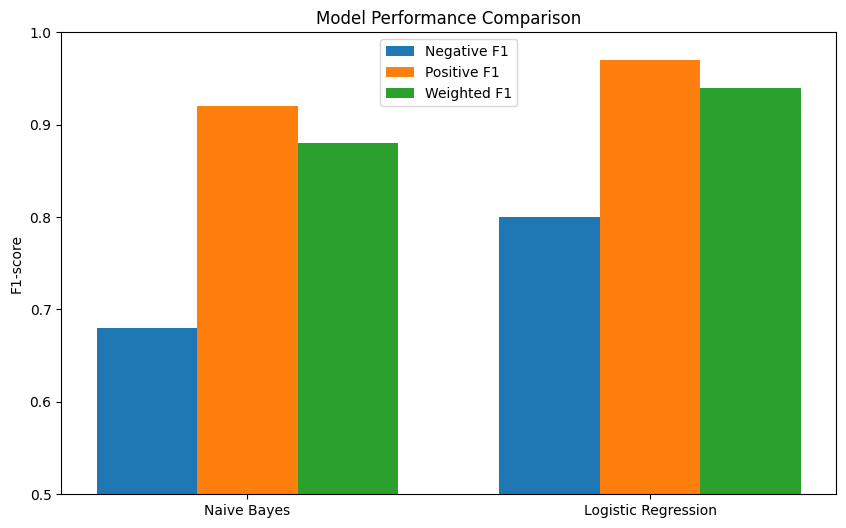

In [105]:
models = ["Naive Bayes", "Logistic Regression"]

neg_f1 = [0.68, 0.80]
pos_f1 = [0.92, 0.97]
weighted_f1 = [0.88, 0.94]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10,6))
plt.bar(x - width, neg_f1, width, label="Negative F1")
plt.bar(x, pos_f1, width, label="Positive F1")
plt.bar(x + width, weighted_f1, width, label="Weighted F1")

plt.xticks(x, models)
plt.ylabel("F1-score")
plt.title("Model Performance Comparison")
plt.ylim(0.5, 1.0)
plt.legend()
plt.show()

## Conclusion

Through preprocessing, TF-IDF feature engineering, and cross-validated model tuning, this project successfully developed an effective sentiment classification system for Amazon product reviews. Multinomial Naive Bayes showed meaningful improvement after hyperparameter tuning, especially for the negative class, with its F1-score rising from 0.26 to 0.71. However, Logistic Regression delivered the most balanced and consistent performance, achieving an F1-score of 0.80 for negative reviews, 0.97 for positive reviews, and a weighted F1-score of 0.94—making it the strongest model overall.

Overall, this project demonstrates how large-scale text data can be transformed into practical insights through machine learning. Automatically classifying reviews as positive or negative allows businesses to understand customer experiences more efficiently, identify issues sooner, and make more informed decisions regarding product development and customer support.